In [1]:
import pandas as pd
import numpy as np

# ── Load 
#https://www.kaggle.com/datasets/blastchar/telco-customer-churn
df = pd.read_csv(r"C:\Users\Crown Tech\Documents\Churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn distribution:\n", df['Churn'].value_counts())
print("\nDtypes:\n", df.dtypes)

# ── Fix TotalCharges (stored as string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("\nTotalCharges nulls after fix:", df['TotalCharges'].isnull().sum())
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# ── Drop customerID  
df.drop('customerID', axis=1, inplace=True)

# ── Convert SeniorCitizen to readable
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# ── Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ── Key stats
print("\n── Key Metrics ─────────")
print(f"Total Customers:   {len(df):,}")
print(f"Churned:           {df['Churn'].sum():,} ({df['Churn'].mean()*100:.1f}%)")
print(f"Retained:          {(df['Churn']==0).sum():,} ({(df['Churn']==0).mean()*100:.1f}%)")
print(f"Avg Monthly Charge: ${df['MonthlyCharges'].mean():.2f}")
print(f"Avg Tenure:        {df['tenure'].mean():.1f} months")

print("\nChurn by Contract Type:")
print(df.groupby('Contract')['Churn'].mean().mul(100).round(1).astype(str) + '%')

print("\nChurn by Internet Service:")
print(df.groupby('InternetService')['Churn'].mean().mul(100).round(1).astype(str) + '%')

# ── Save clean file 
df.to_csv(r"C:\Users\Crown Tech\Documents\Churn\churn_clean.csv", index=False)
print("\n✓ Saved: churn_clean.csv")

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Dtypes:
 customerID           object
gender               object
SeniorCitiz

C:\Users\Crown Tech\AppData\Local\Temp\ipykernel_1196\491762967.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Training samples: 5,634
Test samples:     1,409

── XGBoost Results───
Accuracy:  74.88%
ROC-AUC:   0.8427
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409


── LightGBM Results───
Accuracy:  74.10%
ROC-AUC:   0.8396
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


── Random Forest Results ───
Accuracy:  78.85%
ROC-AUC:   0.8235
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
    

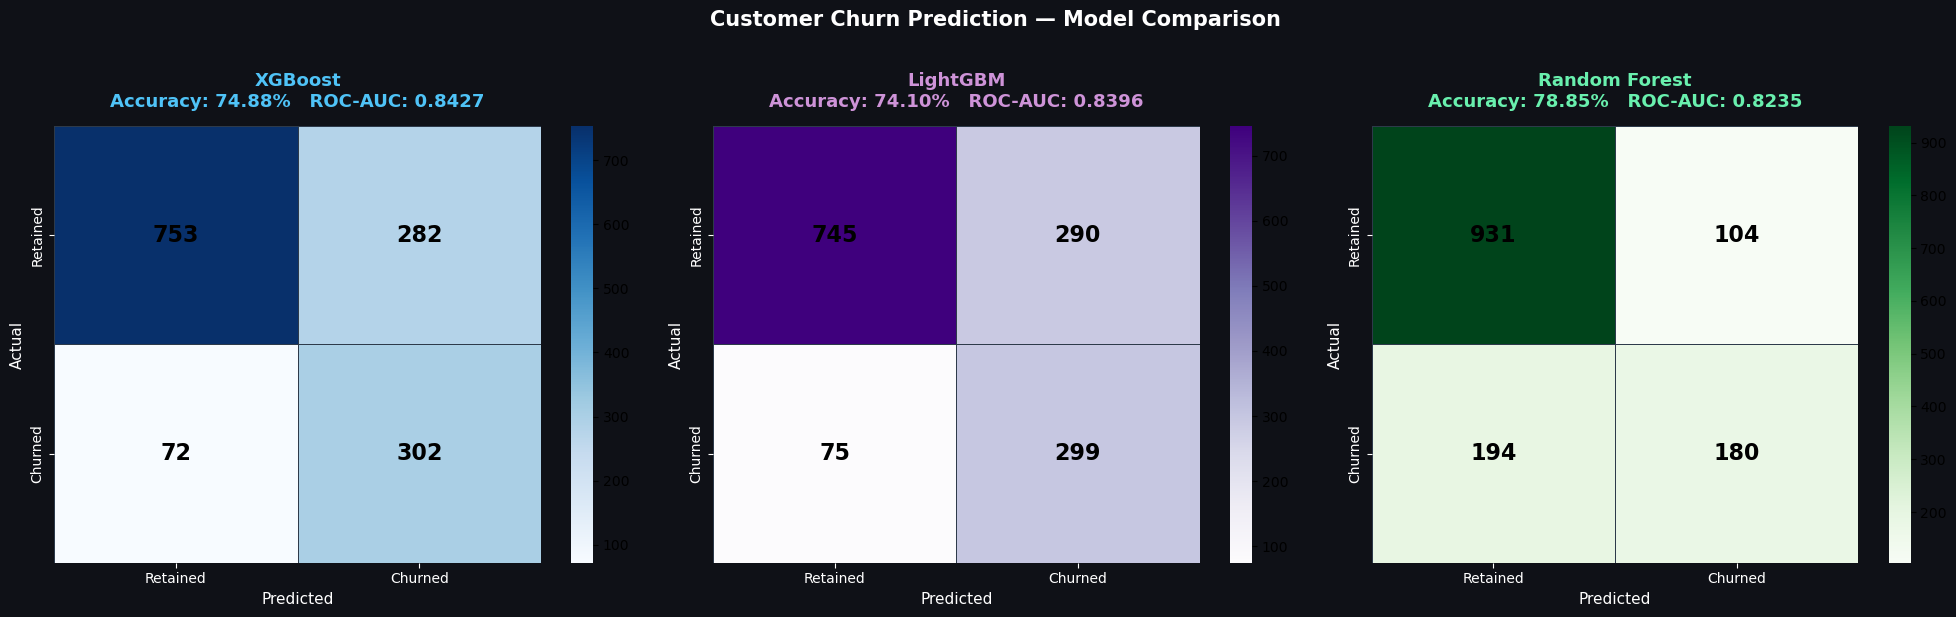

✓ Saved: confusion_matrices.png
✓ Saved XGBoost model (AUC: 0.8427)

── Feature Importance Comparison ──
                  XGBoost  LightGBM  Random Forest
Contract           0.4208    0.0575         0.1113
InternetService    0.0750    0.0000         0.0339
MonthlyCharges     0.0216    0.2521         0.1624
MultipleLines      0.0000    0.0303         0.0000
OnlineBackup       0.0276    0.0000         0.0278
OnlineSecurity     0.0964    0.0333         0.0574
PaperlessBilling   0.0235    0.0241         0.0000
PaymentMethod      0.0212    0.0697         0.0501
SeniorCitizen      0.0000    0.0211         0.0000
StreamingMovies    0.0517    0.0000         0.0000
TechSupport        0.1063    0.0222         0.0481
TotalCharges       0.0000    0.1943         0.1689
gender             0.0000    0.0000         0.0256
tenure             0.0310    0.1824         0.1528

── Top 5 XGBoost ──
  Contract                  0.4208
  TechSupport               0.1063
  OnlineSecurity            0.0964
  In

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib

# ── Load clean data
df = pd.read_csv(r"C:\Users\Crown Tech\Documents\Churn\churn_clean.csv")

# ── Encode categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
encoders = {}
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# ── Features & target
X = df.drop('Churn', axis=1)
y = df['Churn']

# ── Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")

# ── XGBoost 
xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=3, random_state=42, eval_metric='logloss'
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_acc   = accuracy_score(y_test, xgb_preds)
xgb_auc   = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

print(f"\n── XGBoost Results───")
print(f"Accuracy:  {xgb_acc*100:.2f}%")
print(f"ROC-AUC:   {xgb_auc:.4f}")
print(classification_report(y_test, xgb_preds))

# ── LightGBM
lgbm = LGBMClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=3, random_state=42, verbose=-1
)
lgbm.fit(X_train, y_train)
lgbm_preds = lgbm.predict(X_test)
lgbm_acc   = accuracy_score(y_test, lgbm_preds)
lgbm_auc   = roc_auc_score(y_test, lgbm.predict_proba(X_test)[:,1])

print(f"\n── LightGBM Results───")
print(f"Accuracy:  {lgbm_acc*100:.2f}%")
print(f"ROC-AUC:   {lgbm_auc:.4f}")
print(classification_report(y_test, lgbm_preds))

# ── Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)
rf_auc   = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print(f"\n── Random Forest Results ───")
print(f"Accuracy:  {rf_acc*100:.2f}%")
print(f"ROC-AUC:   {rf_auc:.4f}")
print(classification_report(y_test, rf_preds))

# ── Confusion Matrices 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0F1117')

models_info = [
    (axes[0], confusion_matrix(y_test, xgb_preds),
     'XGBoost',       xgb_acc,  xgb_auc,  'Blues',   '#4FC3F7'),
    (axes[1], confusion_matrix(y_test, lgbm_preds),
     'LightGBM',      lgbm_acc, lgbm_auc, 'Purples', '#CE93D8'),
    (axes[2], confusion_matrix(y_test, rf_preds),
     'Random Forest', rf_acc,   rf_auc,   'Greens',  '#69F0AE'),
]

for ax, cm_data, model_name, acc, auc, cmap, title_color in models_info:
    ax.set_facecolor('#1E2B3C')
    sns.heatmap(
        cm_data, annot=True, fmt='d', cmap=cmap, ax=ax,
        xticklabels=['Retained', 'Churned'],
        yticklabels=['Retained', 'Churned'],
        linewidths=0.5, linecolor='#2D3A4A',
        annot_kws={"size": 16, "weight": "bold", "color": "black"}
    )
    ax.set_title(
        f'{model_name}\nAccuracy: {acc*100:.2f}%   ROC-AUC: {auc:.4f}',
        fontsize=13, fontweight='bold', color=title_color, pad=14
    )
    ax.set_ylabel('Actual',    fontsize=11, color='white')
    ax.set_xlabel('Predicted', fontsize=11, color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2D3A4A')

plt.suptitle('Customer Churn Prediction — Model Comparison',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Crown Tech\Documents\Churn\confusion_matrices.png",
    dpi=150, bbox_inches='tight', facecolor='#0F1117'
)
plt.show()
print("✓ Saved: confusion_matrices.png")

# ── Save best model
best_auc   = max(xgb_auc, lgbm_auc, rf_auc)
best_model = {xgb_auc: ('XGBoost', xgb), lgbm_auc: ('LightGBM', lgbm), rf_auc: ('Random Forest', rf)}[best_auc]
joblib.dump(best_model[1], r"C:\Users\Crown Tech\Documents\Churn\churn_model.pkl")
joblib.dump(X.columns.tolist(), r"C:\Users\Crown Tech\Documents\Churn\feature_names.pkl")
print(f"✓ Saved {best_model[0]} model (AUC: {best_auc:.4f})")

# ── Feature importance
print("\n── Feature Importance Comparison ──")
xgb_imp  = pd.Series(xgb.feature_importances_,  index=X.columns).sort_values(ascending=False).head(10)
lgbm_raw = pd.Series(lgbm.feature_importances_, index=X.columns)
lgbm_imp = (lgbm_raw / lgbm_raw.sum()).sort_values(ascending=False).head(10)
rf_imp   = pd.Series(rf.feature_importances_,   index=X.columns).sort_values(ascending=False).head(10)

comparison = pd.DataFrame({
    'XGBoost':       xgb_imp,
    'LightGBM':      lgbm_imp,
    'Random Forest': rf_imp,
}).fillna(0).round(4)
print(comparison.to_string())

print("\n── Top 5 XGBoost ──")
for feat, score in xgb_imp.head(5).items():
    print(f"  {feat:<25} {score:.4f}")

print("\n── Top 5 LightGBM ──")
for feat, score in lgbm_imp.head(5).items():
    print(f"  {feat:<25} {score:.4f}")

print("\n── Top 5 Random Forest──")
for feat, score in rf_imp.head(5).items():
    print(f"  {feat:<25} {score:.4f}")

# ── Final summary 
print("\n── Model Comparison Summary ─")
print(f"  XGBoost       — Accuracy: {xgb_acc*100:.2f}%  |  ROC-AUC: {xgb_auc:.4f}")
print(f"  LightGBM      — Accuracy: {lgbm_acc*100:.2f}%  |  ROC-AUC: {lgbm_auc:.4f}")
print(f"  Random Forest — Accuracy: {rf_acc*100:.2f}%  |  ROC-AUC: {rf_auc:.4f}")
print(f"\n  Best model: {best_model[0]} — saved as churn_model.pkl")